In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 9

DIR_ASLI = 'gambar asli'
DIR_IMAGEJ = 'gambar hasil imageJ'
DIR_PYTHON = 'gambar hasil python'

os.makedirs(DIR_PYTHON, exist_ok=True)

print("Status Direktori:")
print(f"  [√] Direktori gambar asli     : '{DIR_ASLI}' (Ada: {os.path.exists(DIR_ASLI)})")
print(f"  [√] Direktori hasil ImageJ    : '{DIR_IMAGEJ}' (Ada: {os.path.exists(DIR_IMAGEJ)})")
print(f"  [√] Direktori hasil Python    : '{DIR_PYTHON}' (Ada: {os.path.exists(DIR_PYTHON)})")

Status Direktori:
  [√] Direktori gambar asli     : 'gambar asli' (Ada: True)
  [√] Direktori hasil ImageJ    : 'gambar hasil imageJ' (Ada: True)
  [√] Direktori hasil Python    : 'gambar hasil python' (Ada: True)


In [ ]:
path_rokok = os.path.join(DIR_ASLI, 'batang rokok_Grayscale thresholder.jpg')
img_rokok_bgr = cv2.imread(path_rokok)
img_rokok_rgb = cv2.cvtColor(img_rokok_bgr, cv2.COLOR_BGR2RGB)

gray_rokok = cv2.cvtColor(img_rokok_bgr, cv2.COLOR_BGR2GRAY)

otsu_thresh, bin_rokok_otsu = cv2.threshold(gray_rokok, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

_, bin_rokok_std = cv2.threshold(gray_rokok, int(otsu_thresh), 255, cv2.THRESH_BINARY)

path_out_gray = os.path.join(DIR_PYTHON, 'batang_rokok_grayscale.jpg')
path_out_thresh = os.path.join(DIR_PYTHON, 'batang_rokok_threshold_otsu.jpg')
path_out_thresh_std = os.path.join(DIR_PYTHON, 'batang_rokok_threshold_binary.jpg')

cv2.imwrite(path_out_gray, gray_rokok)
cv2.imwrite(path_out_thresh, bin_rokok_otsu)
cv2.imwrite(path_out_thresh_std, bin_rokok_std)

path_rokok_ij = os.path.join(DIR_IMAGEJ, 'batang rokok.jpg')
img_rokok_ij = cv2.imread(path_rokok_ij, cv2.IMREAD_GRAYSCALE)

print(f"Informasi Citra Batang Rokok:")
print(f"  - Dimensi Citra Asli        : {img_rokok_bgr.shape} (RGB 3-channel)")
print(f"  - Dimensi Citra Grayscale   : {gray_rokok.shape} (1-channel)")
print(f"  - Nilai Ambang Otsu Terpilih: T = {otsu_thresh:.1f}")
print(f"  - Persentase Piksel Objek   : {np.mean(bin_rokok_otsu == 255) * 100:.2f}%")
print(f"  [√] Tersimpan di: {path_out_gray} dan {path_out_thresh}")

Informasi Citra Batang Rokok:
  - Dimensi Citra Asli        : (452, 679, 3) (RGB 3-channel)
  - Dimensi Citra Grayscale   : (452, 679) (1-channel)
  - Nilai Ambang Otsu Terpilih: T = 171.0
  - Persentase Piksel Objek   : 12.96%
  [√] Tersimpan di: gambar hasil python\batang_rokok_grayscale.jpg dan gambar hasil python\batang_rokok_threshold_otsu.jpg


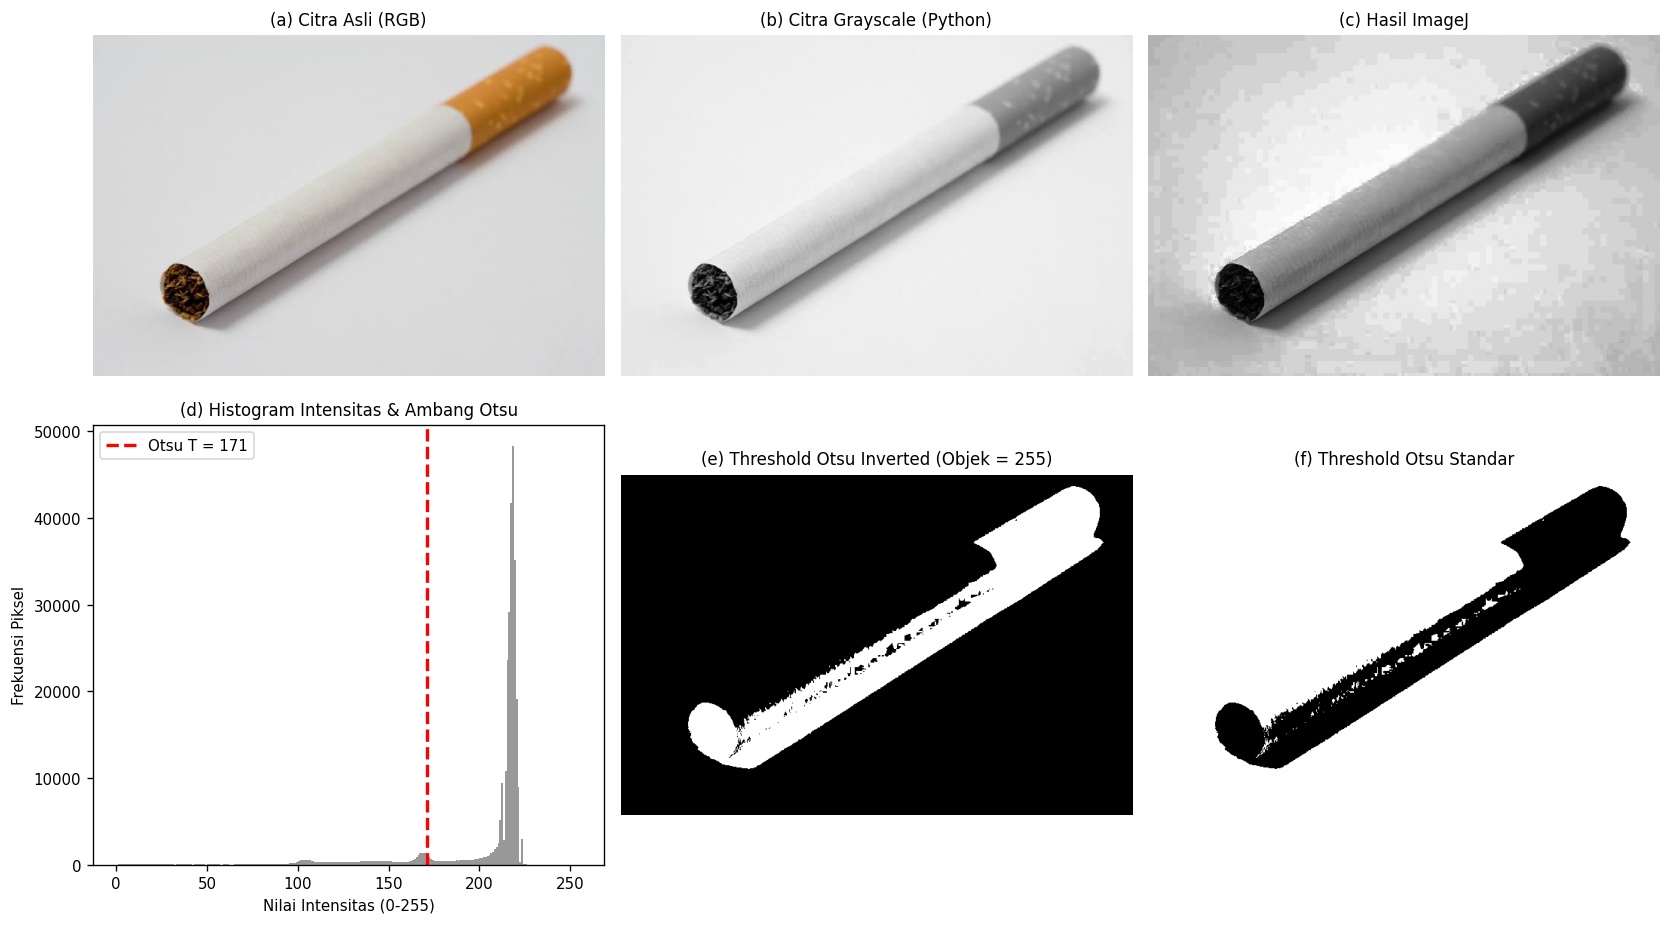

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(img_rokok_rgb)
axes[0, 0].set_title("(a) Citra Asli (RGB)")
axes[0, 0].axis('off')

axes[0, 1].imshow(gray_rokok, cmap='gray')
axes[0, 1].set_title("(b) Citra Grayscale (Python)")
axes[0, 1].axis('off')

axes[0, 2].imshow(img_rokok_ij, cmap='gray')
axes[0, 2].set_title("(c) Hasil ImageJ")
axes[0, 2].axis('off')

axes[1, 0].hist(gray_rokok.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.8)
axes[1, 0].axvline(otsu_thresh, color='red', linestyle='--', linewidth=2, label=f'Otsu T = {otsu_thresh:.0f}')
axes[1, 0].set_title("(d) Histogram Intensitas & Ambang Otsu")
axes[1, 0].set_xlabel("Nilai Intensitas (0-255)")
axes[1, 0].set_ylabel("Frekuensi Piksel")
axes[1, 0].legend()

axes[1, 1].imshow(bin_rokok_otsu, cmap='gray')
axes[1, 1].set_title("(e) Threshold Otsu Inverted (Objek = 255)")
axes[1, 1].axis('off')

axes[1, 2].imshow(bin_rokok_std, cmap='gray')
axes[1, 2].set_title("(f) Threshold Otsu Standar")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
path_bunga = os.path.join(DIR_ASLI, 'bunga_noise.jpg')
img_bunga_bgr = cv2.imread(path_bunga)
img_bunga_rgb = cv2.cvtColor(img_bunga_bgr, cv2.COLOR_BGR2RGB)

smooth_box = cv2.blur(img_bunga_bgr, (5, 5))
smooth_box_rgb = cv2.cvtColor(smooth_box, cv2.COLOR_BGR2RGB)

smooth_gauss = cv2.GaussianBlur(img_bunga_bgr, (5, 5), 1.2)
smooth_gauss_rgb = cv2.cvtColor(smooth_gauss, cv2.COLOR_BGR2RGB)

smooth_median = cv2.medianBlur(img_bunga_bgr, 5)
smooth_median_rgb = cv2.cvtColor(smooth_median, cv2.COLOR_BGR2RGB)

path_out_box = os.path.join(DIR_PYTHON, 'bunga_smooth_box.jpg')
path_out_gauss = os.path.join(DIR_PYTHON, 'bunga_smooth_gaussian.jpg')
path_out_median = os.path.join(DIR_PYTHON, 'bunga_smooth_median.jpg')

cv2.imwrite(path_out_box, smooth_box)
cv2.imwrite(path_out_gauss, smooth_gauss)
cv2.imwrite(path_out_median, smooth_median)

path_bunga_ij = os.path.join(DIR_IMAGEJ, 'bunga_noise.jpg')
img_bunga_ij_bgr = cv2.imread(path_bunga_ij)
img_bunga_ij_rgb = cv2.cvtColor(img_bunga_ij_bgr, cv2.COLOR_BGR2RGB)

print("Informasi Citra Bunga (Smoothing):")
print(f"  - Dimensi Citra Bunga     : {img_bunga_bgr.shape}")
print(f"  - Varians Derau Asli      : {np.var(img_bunga_bgr):.2f}")
print(f"  - Varians Setelah Gaussian: {np.var(smooth_gauss):.2f}")
print(f"  [√] Berkas tersimpan di folder '{DIR_PYTHON}'")

Informasi Citra Bunga (Smoothing):
  - Dimensi Citra Bunga     : (683, 1024, 3)
  - Varians Derau Asli      : 3796.09
  - Varians Setelah Gaussian: 3773.97
  [√] Berkas tersimpan di folder 'gambar hasil python'


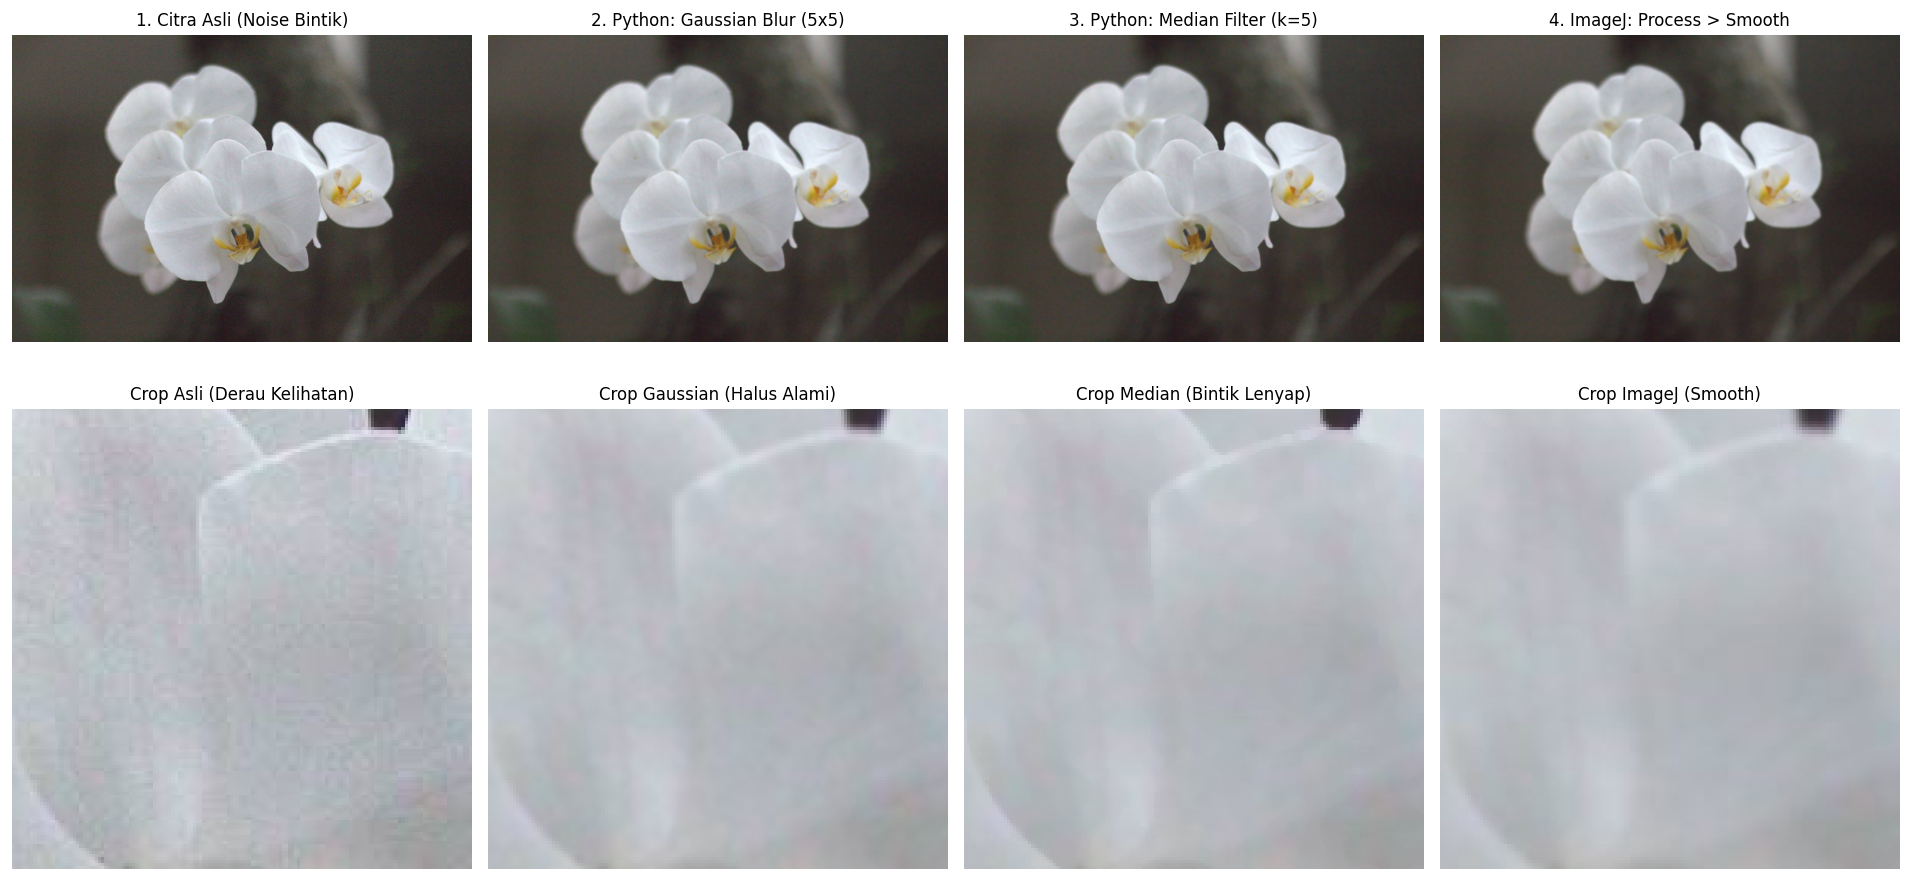

In [ ]:
y1, y2, x1, x2 = 250, 400, 450, 600

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0, 0].imshow(img_bunga_rgb)
axes[0, 0].set_title("1. Citra Asli (Noise Bintik)")
axes[0, 0].axis('off')

axes[0, 1].imshow(smooth_gauss_rgb)
axes[0, 1].set_title("2. Python: Gaussian Blur (5x5)")
axes[0, 1].axis('off')

axes[0, 2].imshow(smooth_median_rgb)
axes[0, 2].set_title("3. Python: Median Filter (k=5)")
axes[0, 2].axis('off')

axes[0, 3].imshow(img_bunga_ij_rgb)
axes[0, 3].set_title("4. ImageJ: Process > Smooth")
axes[0, 3].axis('off')

axes[1, 0].imshow(img_bunga_rgb[y1:y2, x1:x2])
axes[1, 0].set_title("Crop Asli (Derau Kelihatan)")
axes[1, 0].axis('off')

axes[1, 1].imshow(smooth_gauss_rgb[y1:y2, x1:x2])
axes[1, 1].set_title("Crop Gaussian (Halus Alami)")
axes[1, 1].axis('off')

axes[1, 2].imshow(smooth_median_rgb[y1:y2, x1:x2])
axes[1, 2].set_title("Crop Median (Bintik Lenyap)")
axes[1, 2].axis('off')

axes[1, 3].imshow(img_bunga_ij_rgb[y1:y2, x1:x2])
axes[1, 3].set_title("Crop ImageJ (Smooth)")
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
path_merpati = os.path.join(DIR_ASLI, 'merpati_sharpen.jpg')
img_merpati_bgr = cv2.imread(path_merpati)
img_merpati_rgb = cv2.cvtColor(img_merpati_bgr, cv2.COLOR_BGR2RGB)

kernel_laplacian = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

sharp_laplacian = cv2.filter2D(img_merpati_bgr, -1, kernel_laplacian)
sharp_laplacian_rgb = cv2.cvtColor(sharp_laplacian, cv2.COLOR_BGR2RGB)

gaussian_blur_merpati = cv2.GaussianBlur(img_merpati_bgr, (0, 0), sigmaX=2.0)
sharp_unsharp = cv2.addWeighted(img_merpati_bgr, 1.5, gaussian_blur_merpati, -0.5, 0)
sharp_unsharp_rgb = cv2.cvtColor(sharp_unsharp, cv2.COLOR_BGR2RGB)

path_out_laplacian = os.path.join(DIR_PYTHON, 'merpati_sharpen_laplacian.jpg')
path_out_unsharp = os.path.join(DIR_PYTHON, 'merpati_sharpen_unsharp.jpg')

cv2.imwrite(path_out_laplacian, sharp_laplacian)
cv2.imwrite(path_out_unsharp, sharp_unsharp)

path_merpati_ij = os.path.join(DIR_IMAGEJ, 'merpati_sharpen.jpg')
img_merpati_ij_bgr = cv2.imread(path_merpati_ij)
img_merpati_ij_rgb = cv2.cvtColor(img_merpati_ij_bgr, cv2.COLOR_BGR2RGB)

print("Informasi Citra Merpati (Sharpening):")
print(f"  - Dimensi Citra Merpati          : {img_merpati_bgr.shape}")
print(f"  - Standar Deviasi Citra Asli     : {np.std(img_merpati_bgr):.2f}")
print(f"  - Standar Deviasi Hasil Laplacian: {np.std(sharp_laplacian):.2f}")
print(f"  [√] Berkas tersimpan di folder '{DIR_PYTHON}'")

Informasi Citra Merpati (Sharpening):
  - Dimensi Citra Merpati          : (739, 415, 3)
  - Standar Deviasi Citra Asli     : 59.99
  - Standar Deviasi Hasil Laplacian: 63.77
  [√] Berkas tersimpan di folder 'gambar hasil python'


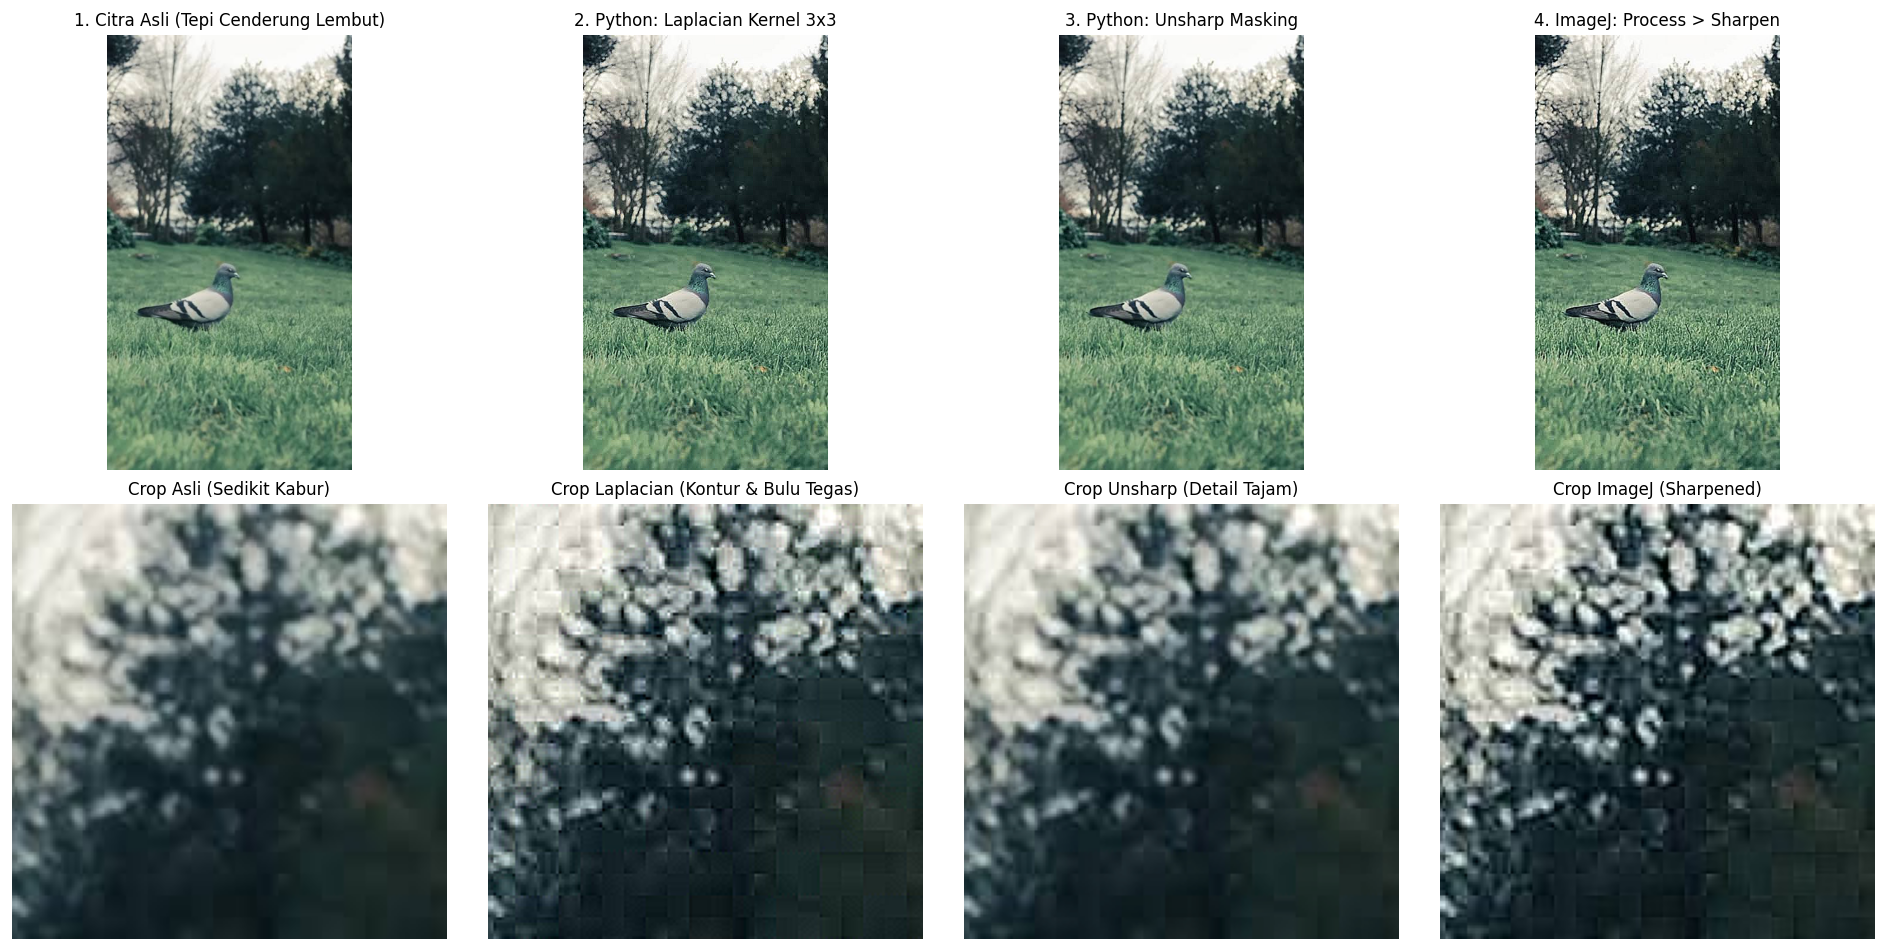

In [ ]:
ym1, ym2, xm1, xm2 = 80, 240, 150, 310

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0, 0].imshow(img_merpati_rgb)
axes[0, 0].set_title("1. Citra Asli (Tepi Cenderung Lembut)")
axes[0, 0].axis('off')

axes[0, 1].imshow(sharp_laplacian_rgb)
axes[0, 1].set_title("2. Python: Laplacian Kernel 3x3")
axes[0, 1].axis('off')

axes[0, 2].imshow(sharp_unsharp_rgb)
axes[0, 2].set_title("3. Python: Unsharp Masking")
axes[0, 2].axis('off')

axes[0, 3].imshow(img_merpati_ij_rgb)
axes[0, 3].set_title("4. ImageJ: Process > Sharpen")
axes[0, 3].axis('off')

axes[1, 0].imshow(img_merpati_rgb[ym1:ym2, xm1:xm2])
axes[1, 0].set_title("Crop Asli (Sedikit Kabur)")
axes[1, 0].axis('off')

axes[1, 1].imshow(sharp_laplacian_rgb[ym1:ym2, xm1:xm2])
axes[1, 1].set_title("Crop Laplacian (Kontur & Bulu Tegas)")
axes[1, 1].axis('off')

axes[1, 2].imshow(sharp_unsharp_rgb[ym1:ym2, xm1:xm2])
axes[1, 2].set_title("Crop Unsharp (Detail Tajam)")
axes[1, 2].axis('off')

axes[1, 3].imshow(img_merpati_ij_rgb[ym1:ym2, xm1:xm2])
axes[1, 3].set_title("Crop ImageJ (Sharpened)")
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()